In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('zomato.csv')

In [7]:
df.head()

,Unnamed: 0.1,Unnamed: 0,restaurant name,restaurant type,rate (out of 5),num of ratings,avg cost (two people),online_order,table booking,cuisines type,area,local address
0,0,0,#FeelTheROLL,Quick Bites,3.4,7,200.0,No,No,Fast Food,Bellandur,Bellandur
1,1,1,#L-81 Cafe,Quick Bites,3.9,48,400.0,Yes,No,"Fast Food, Beverages","Byresandra,Tavarekere,Madiwala",HSR
2,2,2,#refuel,Cafe,3.7,37,400.0,Yes,No,"Cafe, Beverages",Bannerghatta Road,Bannerghatta Road
3,3,3,'@ Biryani Central,Casual Dining,2.7,135,550.0,Yes,No,"Biryani, Mughlai, Chinese",Marathahalli,Marathahalli
4,4,4,'@ The Bbq,Casual Dining,2.8,40,700.0,Yes,No,"BBQ, Continental, North Indian, Chinese, Bever...",Bellandur,Bellandur


In [8]:
df.drop(columns=['Unnamed: 0', 'Unnamed: 0.1'], inplace=True)
df.columns = (df.columns
              .str.strip()
              .str.lower()
              .str.replace(' ', '_')
              .str.replace('[^0-9a-zA-Z_]', '', regex=True))

In [9]:
df['rate_out_of_5'] = pd.to_numeric(df['rate_out_of_5'], errors='coerce')
df['avg_cost_two_people'] = df['avg_cost_two_people'].astype(str).str.replace(',', '').str.strip()
df['avg_cost_two_people'] = pd.to_numeric(df['avg_cost_two_people'], errors='coerce')

In [10]:
df.head()

,restaurant_name,restaurant_type,rate_out_of_5,num_of_ratings,avg_cost_two_people,online_order,table_booking,cuisines_type,area,local_address
0,#FeelTheROLL,Quick Bites,3.4,7,200.0,No,No,Fast Food,Bellandur,Bellandur
1,#L-81 Cafe,Quick Bites,3.9,48,400.0,Yes,No,"Fast Food, Beverages","Byresandra,Tavarekere,Madiwala",HSR
2,#refuel,Cafe,3.7,37,400.0,Yes,No,"Cafe, Beverages",Bannerghatta Road,Bannerghatta Road
3,'@ Biryani Central,Casual Dining,2.7,135,550.0,Yes,No,"Biryani, Mughlai, Chinese",Marathahalli,Marathahalli
4,'@ The Bbq,Casual Dining,2.8,40,700.0,Yes,No,"BBQ, Continental, North Indian, Chinese, Bever...",Bellandur,Bellandur


In [11]:
df['online_order'] = df['online_order'].map({'Yes':1, 'No':0})
df['table_booking'] = df['table_booking'].map({'Yes':1, 'No':0})

In [12]:
df["cost_category"] = pd.cut(
    df["avg_cost_two_people"],
    bins=[0, 500, 1500, 3000, np.inf],
    labels=["Low", "Medium", "High", "Luxury"],
    include_lowest=True
)

df.head()

,restaurant_name,restaurant_type,rate_out_of_5,num_of_ratings,avg_cost_two_people,online_order,table_booking,cuisines_type,area,local_address,cost_category
0,#FeelTheROLL,Quick Bites,3.4,7,200.0,0,0,Fast Food,Bellandur,Bellandur,Low
1,#L-81 Cafe,Quick Bites,3.9,48,400.0,1,0,"Fast Food, Beverages","Byresandra,Tavarekere,Madiwala",HSR,Low
2,#refuel,Cafe,3.7,37,400.0,1,0,"Cafe, Beverages",Bannerghatta Road,Bannerghatta Road,Low
3,'@ Biryani Central,Casual Dining,2.7,135,550.0,1,0,"Biryani, Mughlai, Chinese",Marathahalli,Marathahalli,Medium
4,'@ The Bbq,Casual Dining,2.8,40,700.0,1,0,"BBQ, Continental, North Indian, Chinese, Bever...",Bellandur,Bellandur,Medium


In [13]:
df["primary_cuisine"] = (
    df["cuisines_type"]
    .astype(str)
    .str.split(",")
    .str[0]
    .str.strip()
)

df.head()

,restaurant_name,restaurant_type,rate_out_of_5,num_of_ratings,avg_cost_two_people,online_order,table_booking,cuisines_type,area,local_address,cost_category,primary_cuisine
0,#FeelTheROLL,Quick Bites,3.4,7,200.0,0,0,Fast Food,Bellandur,Bellandur,Low,Fast Food
1,#L-81 Cafe,Quick Bites,3.9,48,400.0,1,0,"Fast Food, Beverages","Byresandra,Tavarekere,Madiwala",HSR,Low,Fast Food
2,#refuel,Cafe,3.7,37,400.0,1,0,"Cafe, Beverages",Bannerghatta Road,Bannerghatta Road,Low,Cafe
3,'@ Biryani Central,Casual Dining,2.7,135,550.0,1,0,"Biryani, Mughlai, Chinese",Marathahalli,Marathahalli,Medium,Biryani
4,'@ The Bbq,Casual Dining,2.8,40,700.0,1,0,"BBQ, Continental, North Indian, Chinese, Bever...",Bellandur,Bellandur,Medium,BBQ


In [14]:
df.isna().sum()

restaurant_name         0
restaurant_type         0
rate_out_of_5          68
num_of_ratings          0
avg_cost_two_people    57
online_order            0
table_booking           0
cuisines_type           0
area                    0
local_address           0
cost_category          57
primary_cuisine         0
dtype: int64

In [15]:
df.dropna(subset=['rate_out_of_5', 'avg_cost_two_people'], inplace=True)

In [16]:
df.shape

(6984, 12)

In [17]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
restaurant_name,6984,6984,#FeelTheROLL,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
restaurant_type,6984,81,Quick Bites,2784,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rate_out_of_5,6984.0,NaN,NaN,NaN,3.514304,0.463489,1.8,3.2,3.5,3.8,4.9
num_of_ratings,6984.0,NaN,NaN,NaN,190.928837,596.717894,1.0,15.0,40.0,130.0,16345.0
avg_cost_two_people,6984.0,NaN,NaN,NaN,542.544244,464.266828,40.0,300.0,400.0,600.0,6000.0
online_order,6984.0,NaN,NaN,NaN,0.532789,0.498959,0.0,0.0,1.0,1.0,1.0
table_booking,6984.0,NaN,NaN,NaN,0.106529,0.308536,0.0,0.0,0.0,0.0,1.0
cuisines_type,6984,2155,"North Indian, Chinese",417,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area,6984,30,"Byresandra,Tavarekere,Madiwala",794,NaN,NaN,NaN,NaN,NaN,NaN,NaN
local_address,6984,90,Whitefield,457,NaN,NaN,NaN,NaN,NaN,NaN,NaN


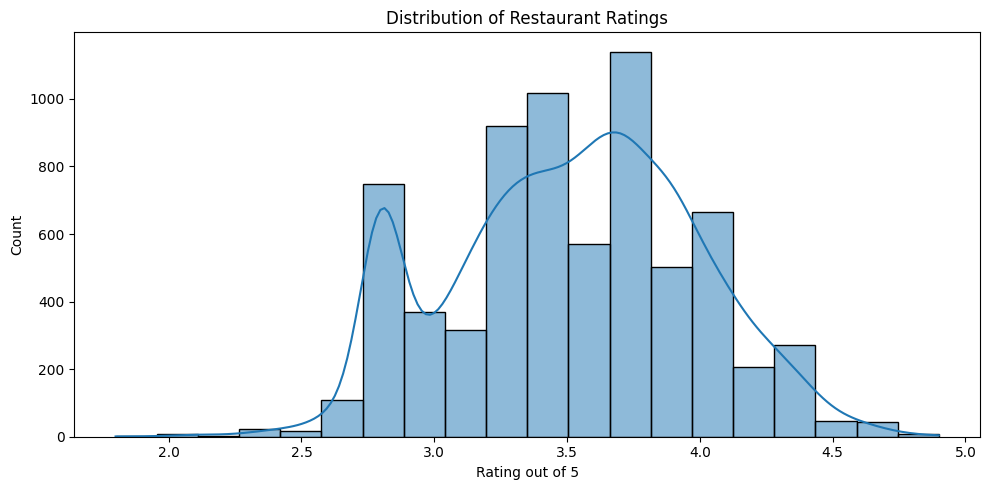

In [18]:
plt.figure(figsize=(10, 5))
sns.histplot(df["rate_out_of_5"], bins=20, kde=True)
plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating out of 5")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

This histogram shows that most restaurants are concentrated in the mid-to-good rating range, roughly around 3.5 to 4.2. It suggests that customer satisfaction is generally positive, while very low or very high ratings appear less frequently.

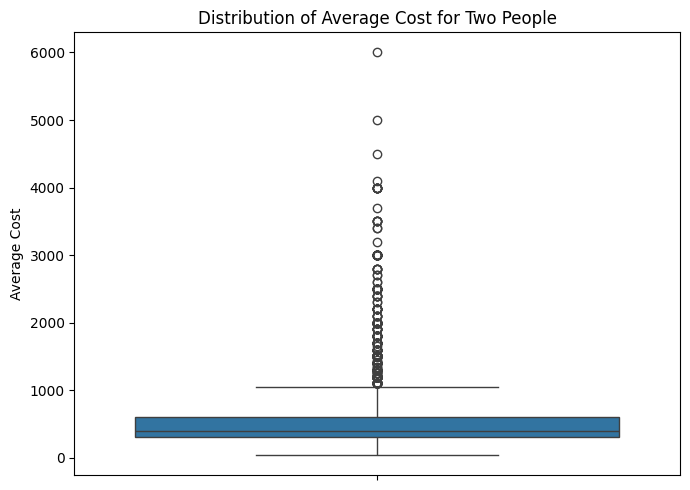

In [19]:
plt.figure(figsize=(7, 5))
sns.boxplot(y=df["avg_cost_two_people"])
plt.title("Distribution of Average Cost for Two People")
plt.ylabel("Average Cost")
plt.tight_layout()
plt.show()

This boxplot highlights that most restaurants fall in the affordable to mid-range pricing segment, while a small number of premium restaurants create high-cost outliers. It reflects that the market is largely driven by budget and mid-segment dining options.

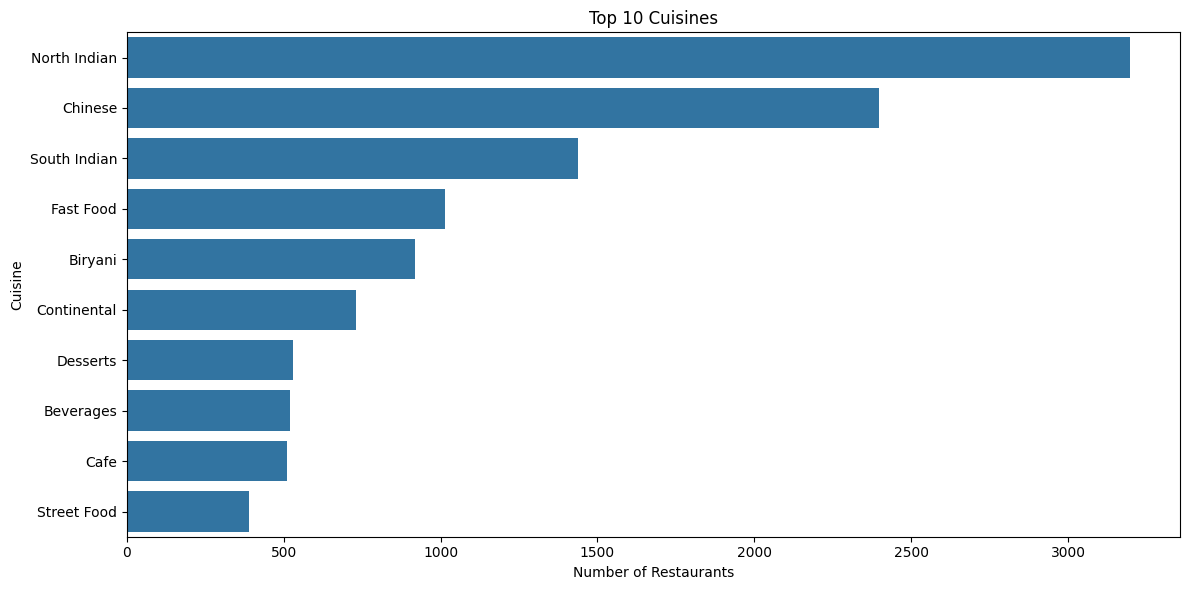

In [20]:
top_cuisines = (
    df["cuisines_type"]
    .astype(str)
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index)
plt.title("Top 10 Cuisines")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")
plt.tight_layout()
plt.show()

This chart shows that restaurant offerings are concentrated around a few popular cuisines. It indicates strong customer preference for certain food types and helps identify cuisines with higher market demand.

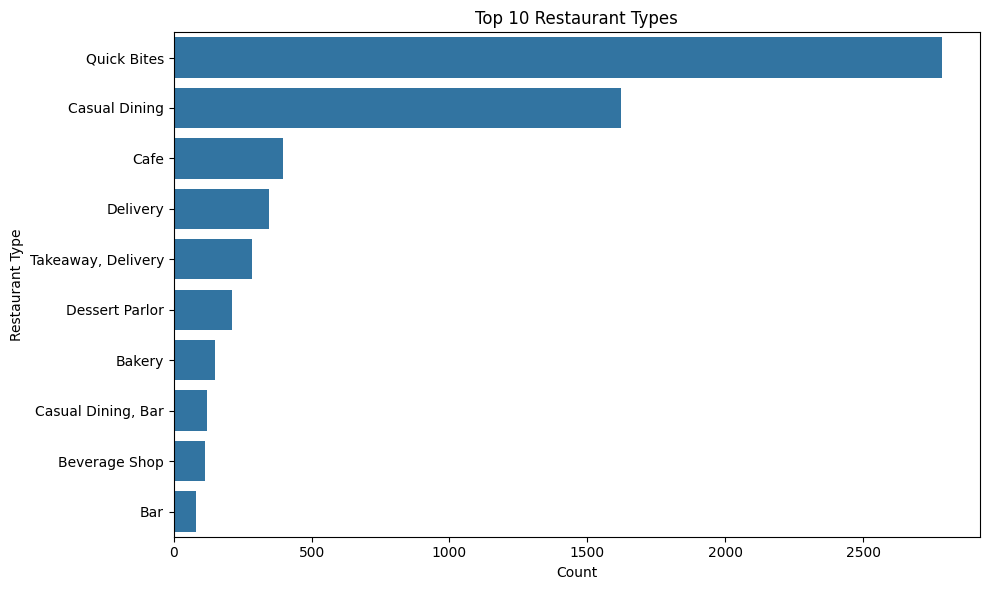

In [21]:
top_restaurant_types = df["restaurant_type"].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_restaurant_types.values, y=top_restaurant_types.index)
plt.title("Top 10 Restaurant Types")
plt.xlabel("Count")
plt.ylabel("Restaurant Type")
plt.tight_layout()
plt.show()

This visualization shows that Quick Bites and Casual Dining are the most common restaurant types in the dataset. It highlights that the market is dominated by convenient and accessible dining formats, helping us understand overall market structure.

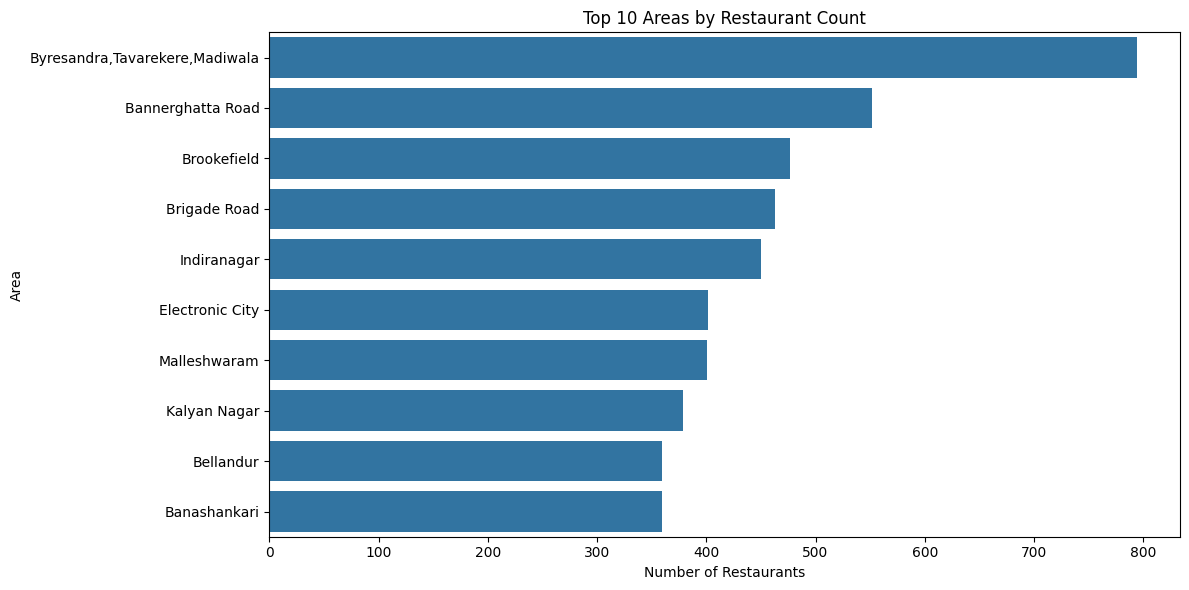

In [22]:
top_areas = df["area"].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_areas.values, y=top_areas.index)
plt.title("Top 10 Areas by Restaurant Count")
plt.xlabel("Number of Restaurants")
plt.ylabel("Area")
plt.tight_layout()
plt.show()

This chart shows the distribution of restaurants across different areas. Areas with a higher restaurant count may represent commercial or high-demand zones, where competition is strong but customer traffic is also likely to be higher.

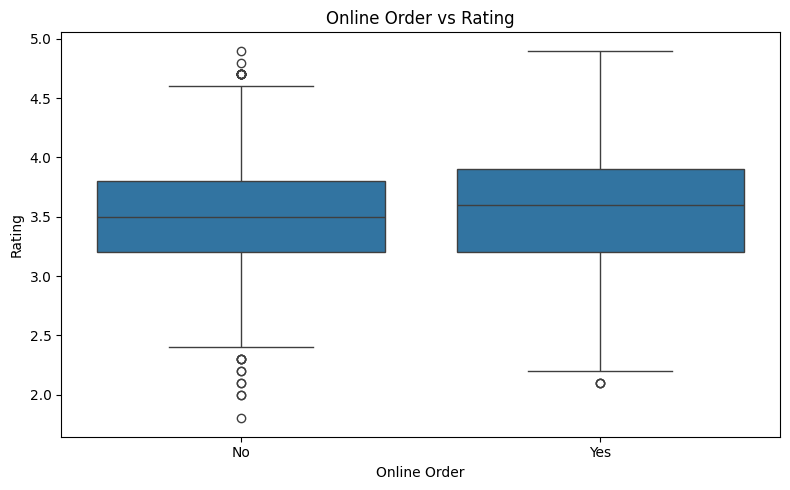

In [23]:
online_labels = {0: "No", 1: "Yes"}

plt.figure(figsize=(8, 5))
sns.boxplot(
    x=df["online_order"].map(online_labels),
    y=df["rate_out_of_5"]
)
plt.title("Online Order vs Rating")
plt.xlabel("Online Order")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

This boxplot compares ratings for restaurants with and without online ordering. It suggests that online ordering may be associated with slightly better or more consistent ratings, possibly due to convenience and wider customer reach.

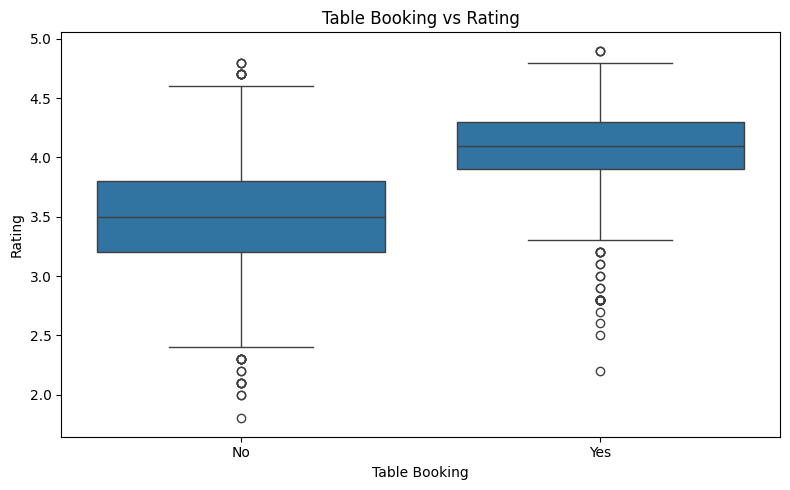

In [24]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    x=df["table_booking"].map(online_labels),
    y=df["rate_out_of_5"]
)
plt.title("Table Booking vs Rating")
plt.xlabel("Table Booking")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

This chart compares customer ratings based on table booking availability. Restaurants offering table booking often appear to receive better ratings, which may indicate a stronger overall customer experience and service quality.

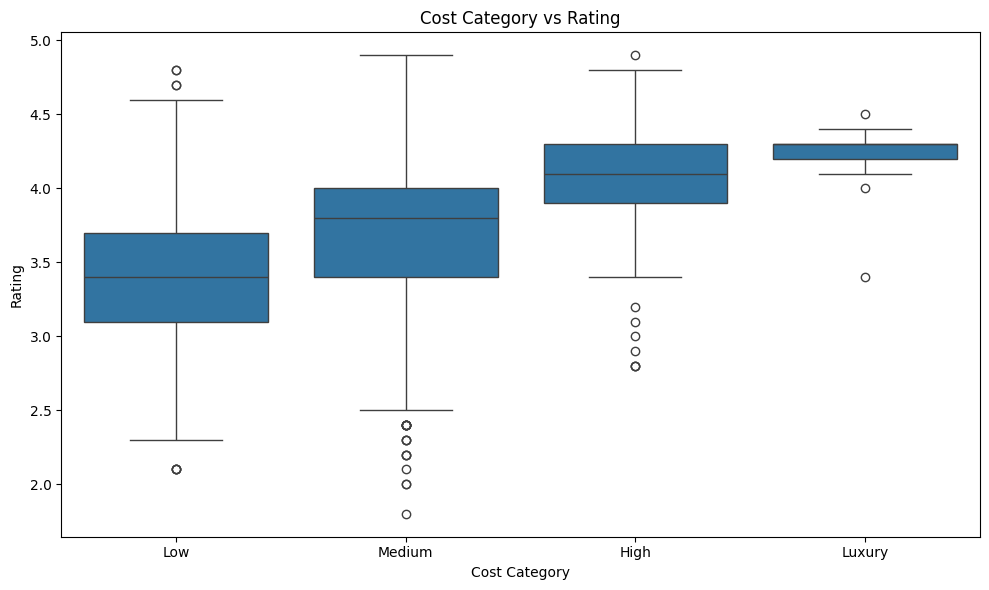

In [25]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    x="cost_category",
    y="rate_out_of_5",
    data=df,
    order=["Low", "Medium", "High", "Luxury"]
)
plt.title("Cost Category vs Rating")
plt.xlabel("Cost Category")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

This plot explores the relationship between restaurant pricing and customer ratings. The trend suggests that higher-priced restaurants may receive slightly better ratings, but the difference is not necessarily very strong. This shows that price alone does not fully determine customer satisfaction.

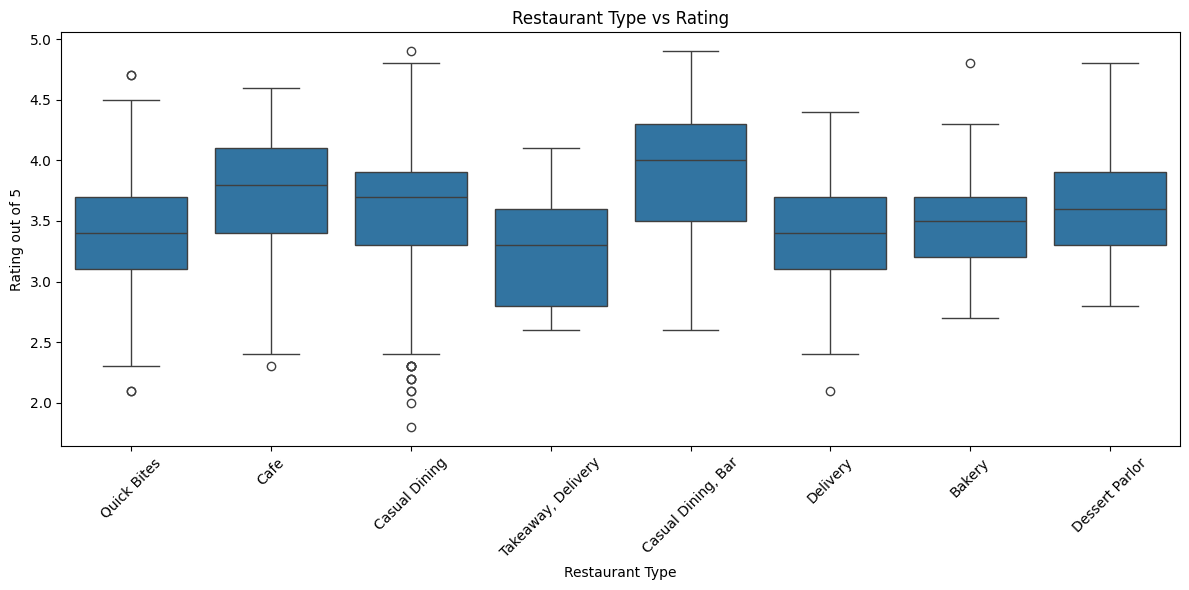

In [26]:
top_types = df["restaurant_type"].value_counts().head(8).index
filtered_df = df[df["restaurant_type"].isin(top_types)]

plt.figure(figsize=(12, 6))
sns.boxplot(x="restaurant_type", y="rate_out_of_5", data=filtered_df)
plt.title("Restaurant Type vs Rating")
plt.xlabel("Restaurant Type")
plt.ylabel("Rating out of 5")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This visualization compares ratings across the most common restaurant types. It helps identify which formats tend to perform consistently well and which ones show more variation in customer feedback.

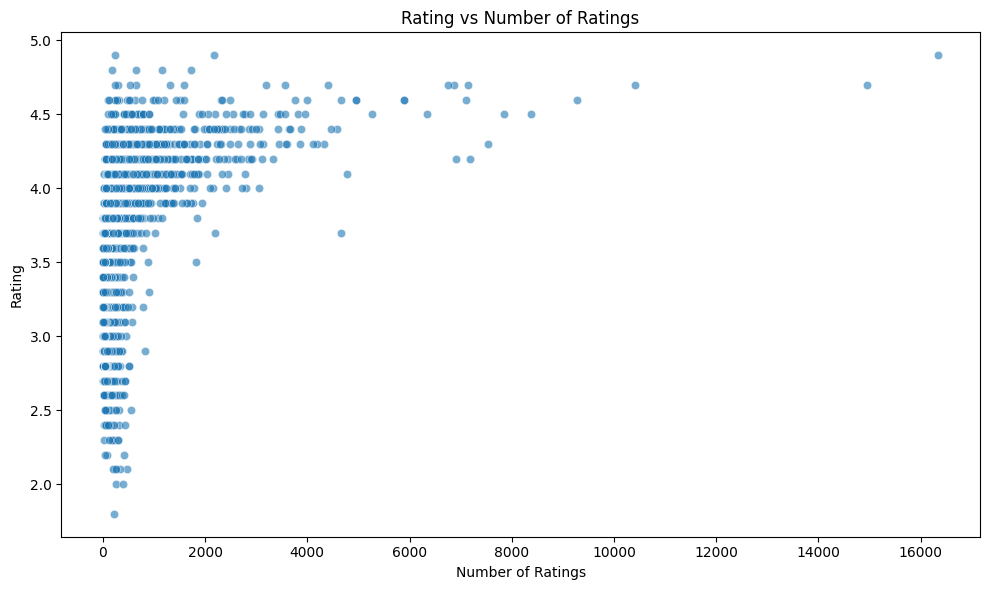

In [27]:
if "num_of_ratings" in df.columns:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        x="num_of_ratings",
        y="rate_out_of_5",
        data=df,
        alpha=0.6
    )
    plt.title("Rating vs Number of Ratings")
    plt.xlabel("Number of Ratings")
    plt.ylabel("Rating")
    plt.tight_layout()
    plt.show()
else:
    print("Column 'num_of_ratings' not found.")

This scatter plot checks whether popular restaurants with more reviews also maintain strong ratings. It shows that high ratings are possible at both low and high review counts, but maintaining very high ratings becomes harder as the number of ratings increases.

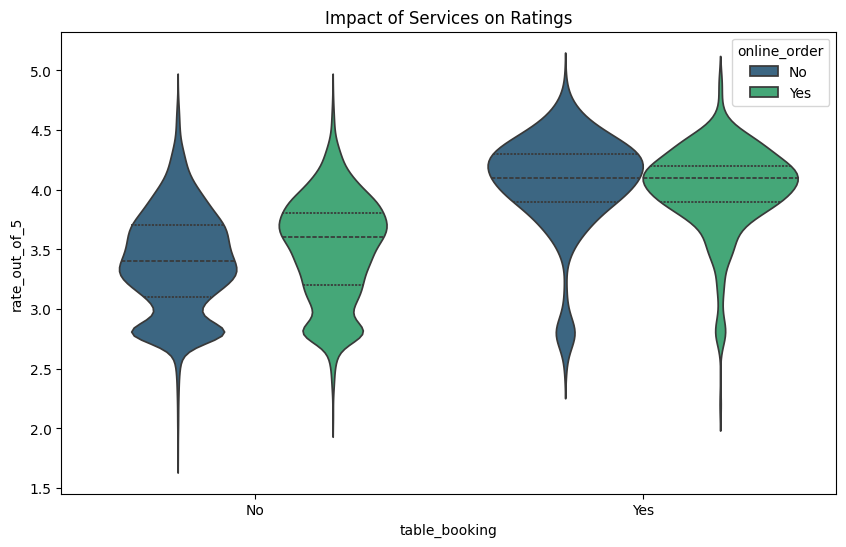

In [76]:
plt.figure(figsize=(10,6))
sns.violinplot(
    x=df['table_booking'].map({0:'No',1:'Yes'}),
    y='rate_out_of_5',
    hue=df['online_order'].map({0:'No',1:'Yes'}),
    data=df,
    palette='viridis',
    inner='quartile'
)
plt.title('Impact of Services on Ratings')
plt.show()

This violin plot combines the rating distribution for table booking and online ordering. It suggests that restaurants offering one or both services often have a healthier concentration of ratings in the upper range, which may indicate better convenience and customer satisfaction.

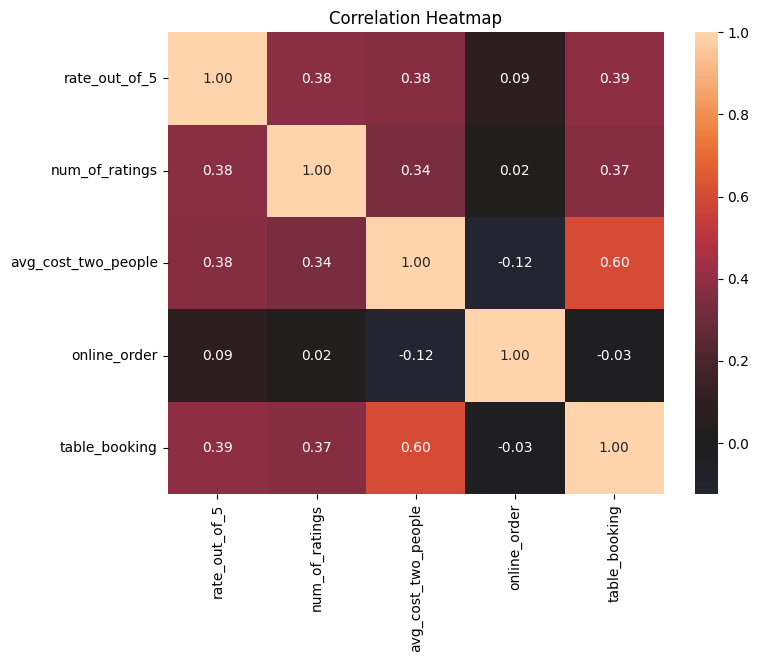

In [71]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", center=0)
plt.title('Correlation Heatmap')
plt.show()


This heatmap summarizes the relationship between numerical variables in the dataset. The correlations appear mostly mild, which suggests that restaurant ratings are influenced by multiple factors rather than just one strong numerical driver.

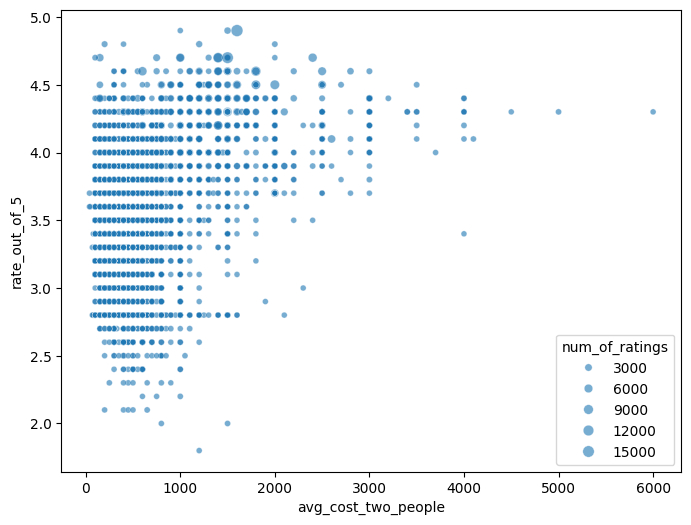

In [74]:
plt.figure(figsize=(8,6))
if "num_of_ratings" in df.columns:
    sns.scatterplot(
        x="avg_cost_two_people",
        y="rate_out_of_5",
        size="num_of_ratings",
        data=df,
        alpha=0.6
    )
else:
    sns.scatterplot(
        x="avg_cost_two_people",
        y="rate_out_of_5",
        data=df,
        alpha=0.6
    )

This scatter plot shows the relationship between cost, ratings, and popularity (number of ratings). 

While higher-cost restaurants may have slightly better ratings, there is no strong linear relationship. 
The size of the points indicates popularity, showing that highly-rated restaurants often attract more reviews. 

It also highlights that some mid-cost restaurants achieve high ratings and strong engagement, making them competitive with expensive restaurants.

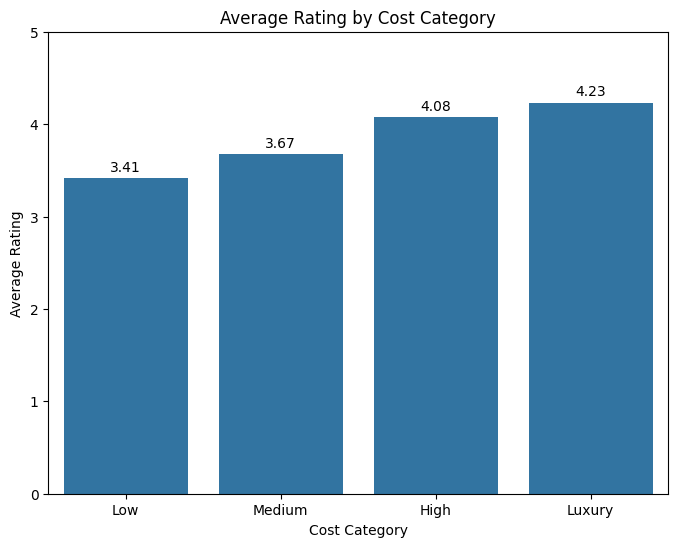

In [62]:
avg_rating_by_cost = df.groupby("cost_category", observed=False)["rate_out_of_5"].mean().reset_index()

plt.figure(figsize=(8, 6))
ax = sns.barplot(x="cost_category", y="rate_out_of_5", data=avg_rating_by_cost, order=["Low","Medium","High","Luxury"])

ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)

plt.title("Average Rating by Cost Category")
plt.xlabel("Cost Category")
plt.ylabel("Average Rating")
plt.ylim(0, 5)
plt.show()

This bar chart shows the average rating across different cost categories. 
It provides a clearer comparison than boxplots by focusing on mean values. 
The results suggest that higher-cost restaurants tend to have slightly higher average ratings, 
but the difference is not very large, indicating that affordability does not necessarily mean poor quality.

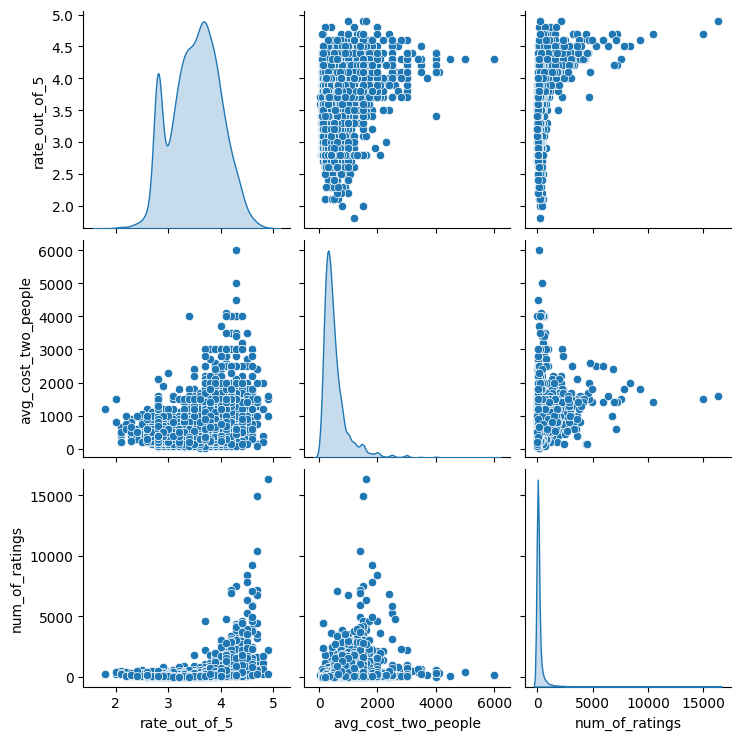

In [77]:
cols = ["rate_out_of_5", "avg_cost_two_people"]

if "num_of_ratings" in df.columns:
    cols.append("num_of_ratings")

sns.pairplot(df[cols].dropna(), diag_kind="kde")
plt.show()

This pairplot provides a compact summary of the relationships between the main numerical variables. It helps us see both the distribution of each variable and the pairwise patterns among them, making it a useful final overview of the dataset.

## Insights & Business Recommendations

### Key Insights

- Ratings Distribution: Most restaurants have ratings between 3.5 and 4.5, indicating generally positive customer satisfaction across the platform.
- Cost vs Rating: Higher cost does not guarantee better ratings, as many mid-range restaurants achieve comparable or even higher customer satisfaction.
- Top Cuisines: Popular cuisines such as North Indian, Chinese, and Fast Food dominate the dataset, reflecting strong and consistent customer demand.
- Popular Areas: Certain areas have a high concentration of restaurants, suggesting both strong demand and intense competition.
- Online Ordering & Table Booking: Restaurants offering these services tend to show slightly better and more consistent ratings, possibly due to improved convenience and customer experience.
- Correlation Patterns: Most relationships between numerical variables are mild, indicating that ratings are influenced by multiple factors rather than a single dominant factor.

### Business Recommendations

- Focus on Mid-Range Pricing: Mid-cost restaurants often achieve strong ratings, making them a balanced and competitive business option.
- Enable Online Ordering: Restaurants should adopt online ordering systems, as it improves reach and may lead to more consistent customer ratings.
- Leverage Table Booking: Table booking should be emphasized for premium restaurants to enhance customer experience.
- Target High-Demand Areas: Opening or promoting restaurants in high-density areas can increase visibility, but differentiation is necessary due to competition.
- Promote Popular Cuisines: Focusing on high-demand cuisines can improve customer acquisition and success rate.
- Improve Underperforming Restaurants: Identify low-rated restaurants and enhance service quality, pricing, or customer experience.
- Balance Rating and Review Volume: Restaurants with both high ratings and a large number of reviews are more reliable and should be prioritized.

### Final Conclusion

This analysis shows that restaurant success is not driven by a single factor. 
Instead, a combination of pricing, service availability, cuisine type, and location 
collectively influence customer ratings.

Mid-range restaurants with strong service offerings and presence in high-demand 
areas tend to perform the best.